# Dutch Road Sign Recognizer

Ivan Milokhodov, 2026

This notebook builds a CNN image classifier that predicts the type of a Dutch road sign from a phone-camera photo and returns the official Dutch name of the sign alongside a plain-English explanation of the rule it enforces — something a person studying for the Dutch CBR theory exam can use in the moment to identify an unfamiliar sign.

The project follows the AMD Project Methodology end-to-end and iterates on the model across several training runs.

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))
import numpy, pandas, matplotlib.pyplot as plt, seaborn
import torch, torchvision
from PIL import Image
import data as D, modeling as M
from nl_classes import NL_SIGN_INFO, NL_CLASS_KEYS, describe
DEVICE = M.get_device()
print('numpy', numpy.__version__, '| pandas', pandas.__version__)
print('torch', torch.__version__, '| torchvision', torchvision.__version__)
print('device:', DEVICE)
DATA = REPO_ROOT / 'data'
CROPS_DIR = DATA / 'nl_crops'
ANNOT_DIR = DATA / 'annotations'
ANNOT_READY = ANNOT_DIR.exists() and any(ANNOT_DIR.glob('*.json'))
CROPS_READY = CROPS_DIR.exists() and any((p.is_dir() for p in CROPS_DIR.iterdir()))
print('annotations present:', ANNOT_READY, '| crops present:', CROPS_READY)

numpy 2.4.6 | pandas 3.0.3
torch 2.12.0 | torchvision 0.27.0
device: mps
annotations present: False | crops present: True


## 1. Domain Understanding

Preparing for the Dutch CBR theory exam involves memorising a large, varied set of road signs. Many Dutch signs differ from those used elsewhere and are not self-evident from their design. For someone who has not driven in the Netherlands, an unfamiliar sign in a practice question is shown but its meaning is not obvious, and the Dutch-language explanation in apps such as the official CBR app and theorie.nl may not be accessible without Dutch language skills.

Existing tools require you to already know which sign you are looking at to look it up — they offer no image-recognition interface. General image search can name a sign but does not reliably give the official Dutch name, the associated rule in plain English, or a confidence measure.

Opportunity. A CNN trained on labelled road-sign images, filtered to the classes that appear in Dutch signage, can take a photo and return the predicted class, its official Dutch name, and a one-line plain-English explanation of the rule it enforces.

Stakeholder. A person currently getting their driver's licence in the Netherlands and actively preparing for the CBR theory exam. Their experience shapes which classes to prioritise, what accuracy is useful, and what a meaningful output looks like.

Cost of mistakes. A confidently wrong identification is worse than no answer - it could teach the wrong rule before an exam. This is why the output exposes the top-3 predictions with confidence scores, not a single unqualified label.

## 2. Analytic Approach

Research question. Can a fine-tuned CNN classifier, trained on the NL-filtered subset of the Mapillary Traffic Sign Dataset, recognise Dutch road signs from a phone-camera photo accurately enough to help a person studying for the Dutch CBR theory exam identify signs they encounter in practice questions?

Sub-questions framing the iteration loop:
1. Which subset of Mapillary's classes appears in Dutch signage, and how many training examples does each NL-relevant class have after filtering?
2. How much accuracy is lost on photos collected in the Netherlands versus the Mapillary held-out test split, and where does the model fail most?
3. Does the predicted class + Dutch name + plain-English explanation actually reduce the stakeholder's confusion during theory-exam practice?

Problem type. Image classification. Target: a categorical sign-class label. Input: one phone photo with one sign as the dominant subject. Output: a probability distribution over the NL-relevant classes. This satisfies the challenge requirement that the product predicts something.

Evaluation metrics. Top-1 and top-3 accuracy, per-class accuracy, and a confusion matrix. The *primary, stakeholder-facing threshold* is measured on the field-collected NL set (real usage conditions), per AMD step 3 which evaluates inference against real client data. The Mapillary held-out split is a secondary, pipeline-health metric.

## 3. Data Requirements

Primary training source - Mapillary Traffic Sign Dataset (MTSD). 52,000 images, 313 sign classes worldwide, with bounding-box and class annotations. Also added scraped data for classes not represented in the dataset.

## 4. Data Collection

In [2]:
print(f'Curated NL set: {len(NL_CLASS_KEYS)} classes')
for k in NL_CLASS_KEYS:
    print(f"  {k:<48} {describe(k)['nl']}")

Curated NL set: 43 classes
  information--motorway--g1                        Autosnelweg (G1)
  information--parking--g1                         Parkeergelegenheid (E4)
  information--pedestrians-crossing--g1            Voetgangersoversteekplaats / zebrapad (L2)
  information--tram-bus-stop--g2                   Tram- of bushalte (L3)
  nl--busbaan--l                                   Busbaan / OV-baan
  nl--fietsstraat--auto-te-gast                    Fietsstraat ‘auto te gast’
  nl--milieuzone--c22a                             Milieuzone (C22a)
  nl--parkeerschijfzone-begin--e10                 Parkeerschijf-zone (E10)
  nl--woonerf-begin--g5                            Woonerf (G5)
  nl--woonerf-einde--g6                            Einde woonerf (G6)
  regulatory--bicycles-only--g1                    Verplicht (brom)fietspad (G11)
  regulatory--go-straight--g1                      Gebod rechtdoor (D4)
  regulatory--height-limit--g1                     Maximale doorrijhoogte (C19)
  

In [3]:
from collections import Counter
import json
if ANNOT_READY:
    all_labels = Counter()
    for jf in ANNOT_DIR.glob('*.json'):
        try:
            d = json.loads(jf.read_text())
        except json.JSONDecodeError:
            continue
        for o in d.get('objects', []):
            if o.get('label'):
                all_labels[o['label']] += 1
    print(f'{len(all_labels)} distinct labels across {sum(all_labels.values())} sign objects. Top 12:')
    for lab, n in all_labels.most_common(12):
        print(f"  {n:>6}  {lab} {('<- NL' if lab in NL_SIGN_INFO else '')}")
    missing = [k for k in NL_CLASS_KEYS if k not in all_labels]
    print('\nCurated NL keys missing from data:', missing or 'none')
    nl_total = sum((all_labels[k] for k in NL_CLASS_KEYS if k in all_labels))
    print(f'NL sign instances available: {nl_total} across {len(NL_CLASS_KEYS)} classes')
else:
    print('Annotations not present — see DATA.md.')

Annotations not present — see DATA.md.


## 5. Data Preparation

Answers sub-question 1. Each NL-relevant sign is cropped out of its full Mapillary frame (with a small context margin) into a per-class folder data/raw/nl_crops/<label>/, done once by scripts/prepare_crops.py. Pre-cropping turns ~34 GB of full street frames into a compact set of single-sign images, so the bulky frames can be deleted and training is fast. We then verify the per-class crop counts.

In [4]:
if CROPS_READY:
    items = D.list_crops(CROPS_DIR)
    counts = pandas.Series([lab for _, lab in items]).value_counts()
    print(f'{len(items)} crops across {len(counts)} classes')
    display(counts.rename('crops').to_frame())
else:
    items, counts = ([], pandas.Series(dtype=int))
    print('crops not built yet — run scripts/prepare_crops.py (see cell above)')

25340 crops across 43 classes


,crops
regulatory--yield--g1,2523
information--pedestrians-crossing--g1,2171
regulatory--no-entry--g1,1733
regulatory--stop--g1,1362
information--parking--g1,1353
regulatory--no-stopping--g15,1226
regulatory--no-parking--g1,1174
warning--pedestrians-crossing--g4,1114
regulatory--priority-road--g4,1113
regulatory--keep-right--g1,1112


## 6. Exploratory Data Analysis

Class balance and image quality before training: the per-class count distribution and a grid of sample cropped signs.

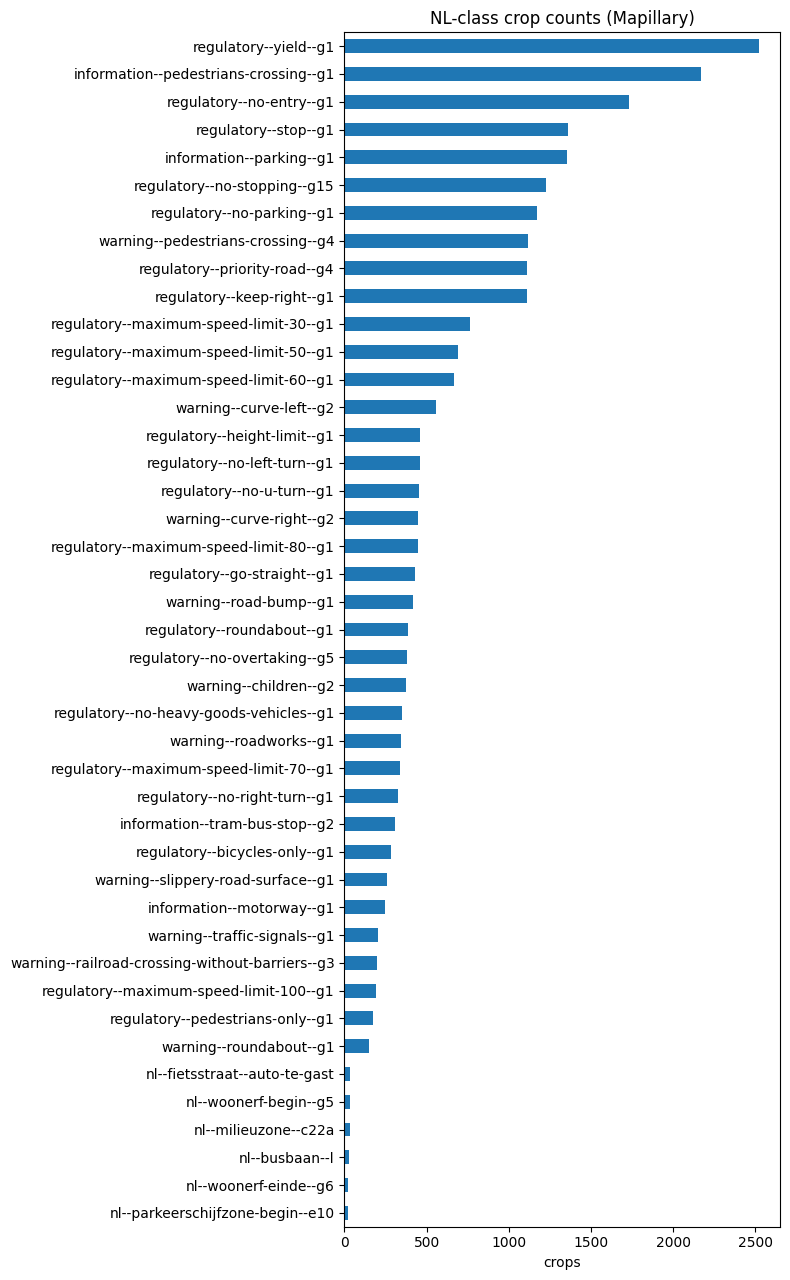

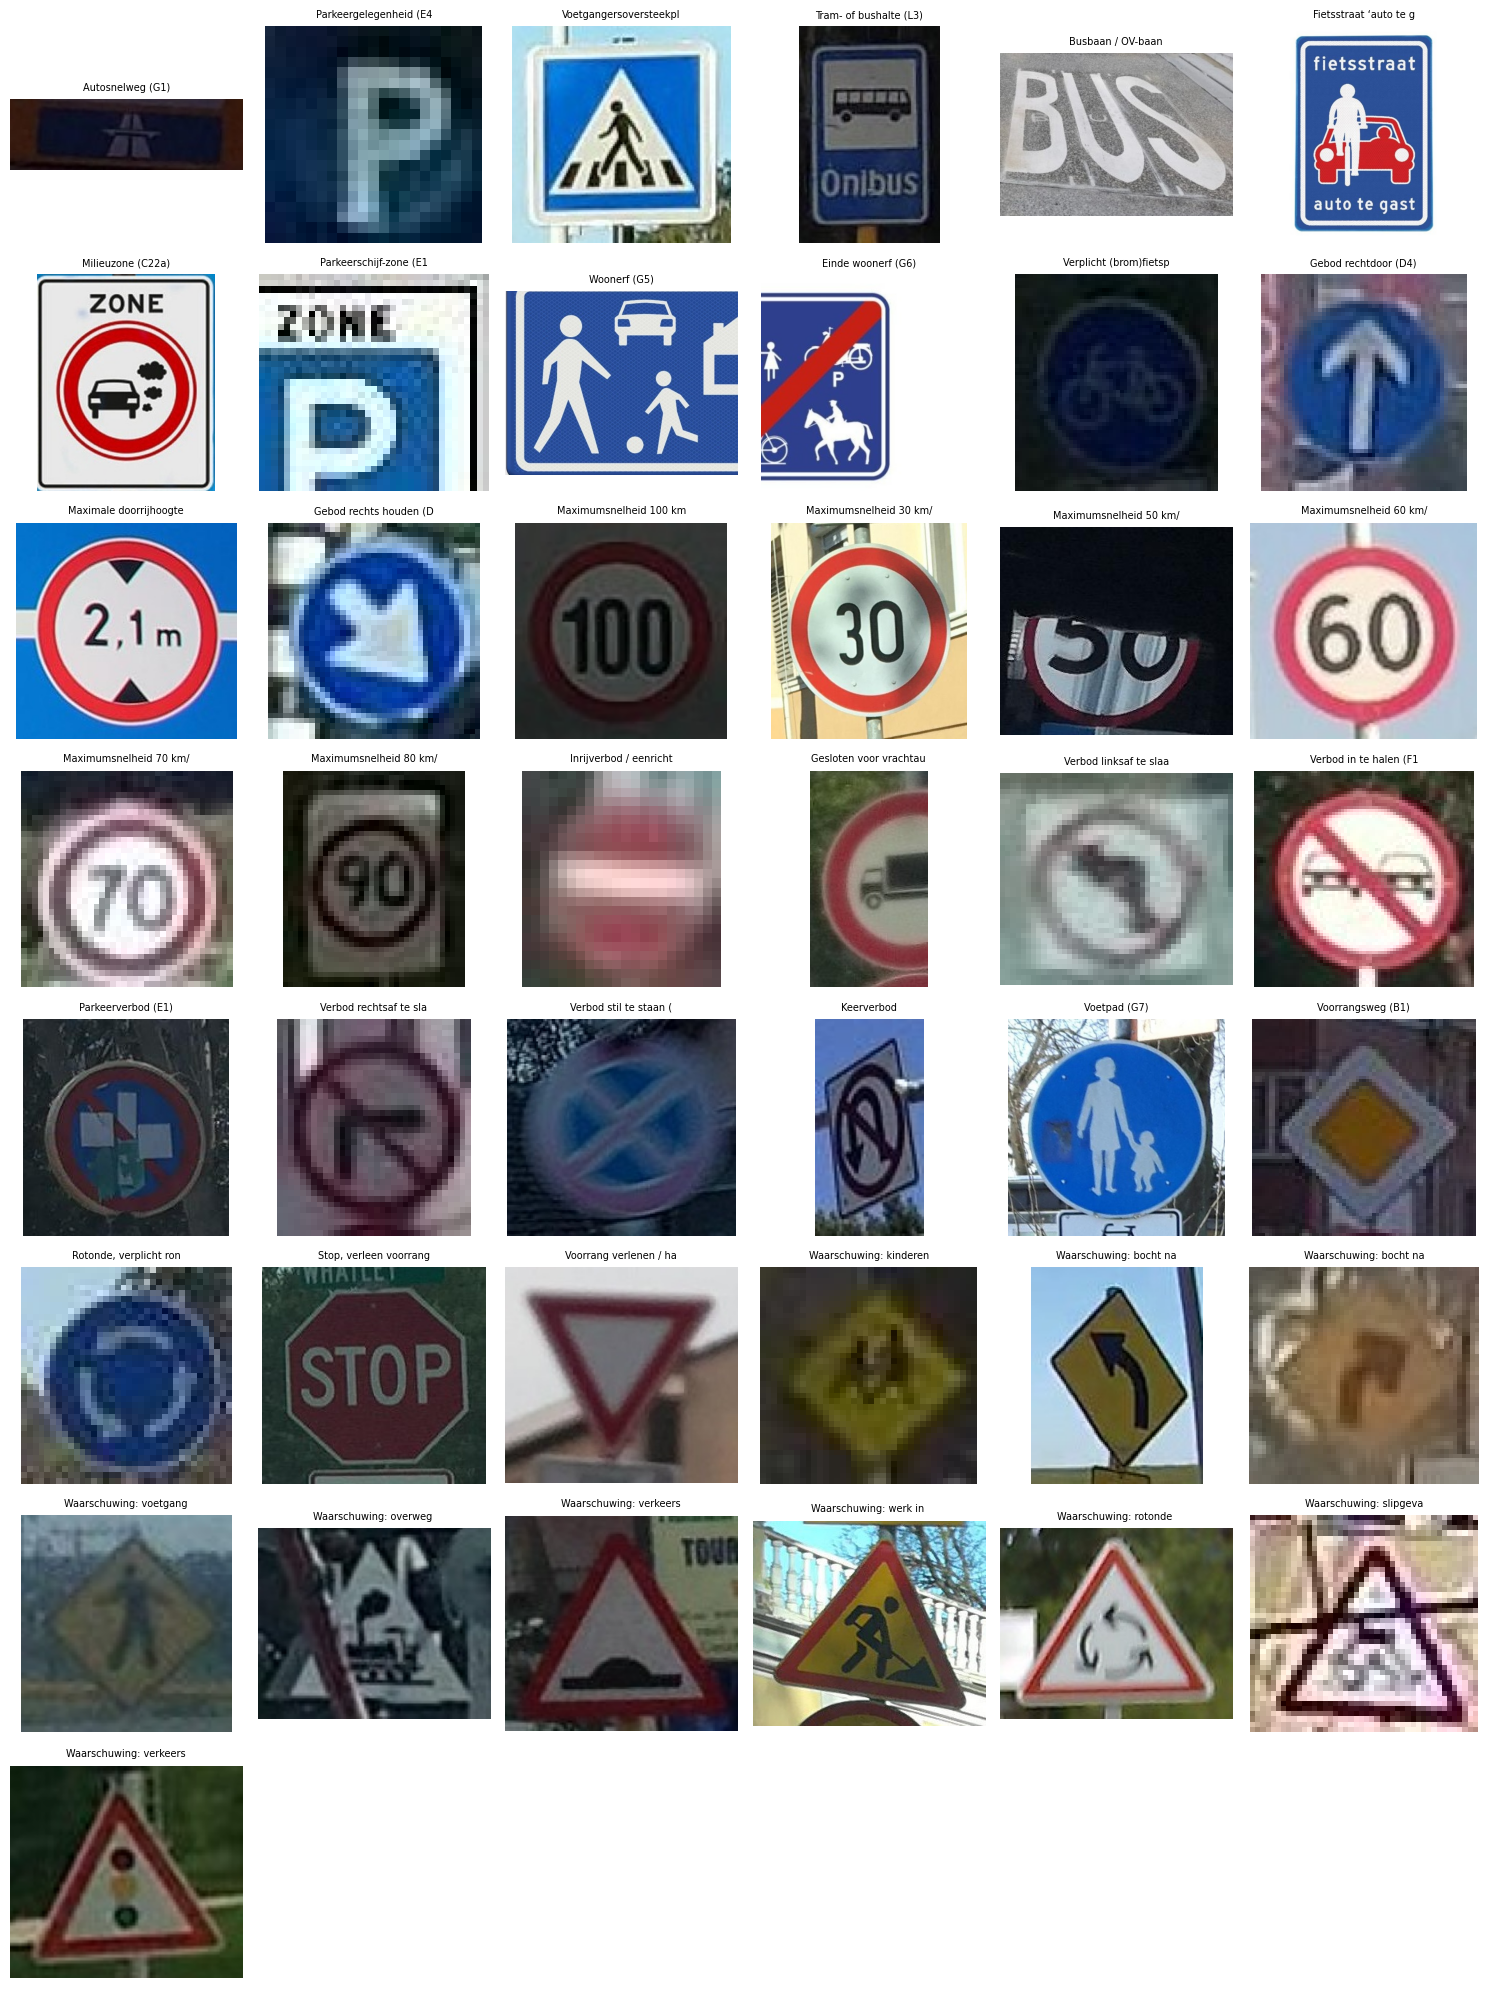

In [5]:
if CROPS_READY and len(counts):
    counts.sort_values().plot(kind='barh', figsize=(8, max(3, 0.3 * len(counts))))
    plt.title('NL-class crop counts (Mapillary)')
    plt.xlabel('crops')
    plt.tight_layout()
    plt.show()
    seen = {}
    for path, lab in items:
        seen.setdefault(lab, path)
    cols = min(6, len(seen))
    rows = (len(seen) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5 * rows))
    axes = numpy.array(axes).reshape(-1)
    for ax, (lab, path) in zip(axes, seen.items()):
        ax.imshow(Image.open(path))
        ax.set_title(describe(lab)['nl'][:22], fontsize=7)
        ax.axis('off')
    for ax in axes[len(seen):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('awaiting crops')

## 7. Feature Preparation

In [6]:
if CROPS_READY and items:
    classes = sorted(counts.index)
    train, val, test = D.stratified_split_items(items)
    class_to_idx, idx_to_class = D.build_class_index(classes)
    train_tf, eval_tf = D.build_transforms()
    train_loader = D.make_loader(D.CropDataset(train, class_to_idx, train_tf), batch_size=64, shuffle=True)
    val_loader = D.make_loader(D.CropDataset(val, class_to_idx, eval_tf), batch_size=64)
    test_loader = D.make_loader(D.CropDataset(test, class_to_idx, eval_tf), batch_size=64)
    print(f'train/val/test = {len(train)}/{len(val)}/{len(test)} | classes = {len(classes)}')
else:
    print('awaiting crops')

train/val/test = 17736/3802/3802 | classes = 43


## 8. Modelling: Iteration 1 (baseline)

A pretrained ResNet-18 is fine-tuned on the NL crop set. The final layer is replaced with one output per class, and the model is trained with the augmentation from section 7 and a cosine learning rate schedule.

The baseline runs for 5 epochs on the 37 Mapillary classes plus the 6 Dutch-exclusive classes built from raw scraped web images. It reaches 98.8% top-1 and 99.8% top-3 on the held-out Mapillary split.

Two problems show up when the baseline is tested on real photos:

1. The Dutch-exclusive classes were trained on uncurated web images. Woonerf in particular absorbed generic street scenes and became a sink class, so almost any street-like photo was classified as woonerf.
2. The model classifies one dominant sign per photo, but Dutch poles often carry several signs at once.

In [ ]:
EPOCHS = 5
if CROPS_READY and items:
    baseline = M.build_model(len(classes), backbone='resnet18', device=DEVICE)
    hist_b = M.train_model(baseline, train_loader, val_loader, epochs=EPOCHS, lr=0.0001, device=DEVICE, log=print, tag='resnet18-baseline')
    held_b = M.evaluate_topk(baseline, test_loader, device=DEVICE)
    print(f"Baseline held-out: top-1 {held_b['top1']:.3f} | top-3 {held_b['top3']:.3f}  ({len(test)} crops)")
else:
    print('awaiting crops')

## 9. Modelling: Iteration 2 (curated data and multi-sign detection)

Based on iteration 1, two changes are made.

1. Curated Dutch-exclusive data. Each scraped image for the 6 NL-only classes is reviewed by hand (keep or drop) and cropped to the sign. Training is extended to 14 epochs on the cleaned set.
2. Detect then classify. A YOLO detector proposes sign boxes and the classifier labels each one, so a photo with several signs is handled instead of only the single dominant sign.

On a hand-picked validation set (one real photo per class through the full detect and classify pipeline), top-1 rose from 88% to 95.3%, top-3 reached 100%.

In [ ]:
EPOCHS = 14
if CROPS_READY and items:
    model = M.build_model(len(classes), backbone='resnet18', device=DEVICE)
    hist = M.train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=0.0001, device=DEVICE, log=print, tag='resnet18')
    curve = pandas.DataFrame({'epoch': range(1, len(hist.train_loss) + 1), 'train_loss': hist.train_loss, 'val_top1': hist.val_top1})
    display(curve.round(4))
else:
    print('awaiting crops — see DATA.md')

In [9]:
if CROPS_READY and items:
    held = M.evaluate_topk(model, test_loader, device=DEVICE)
    print(f"Held-out test: top-1 {held['top1']:.3f} | top-3 {held['top3']:.3f}  ({len(test)} crops)")
    MODELS = REPO_ROOT / 'model'
    MODELS.mkdir(exist_ok=True)
    M.save_model(model, MODELS / 'best_resnet18.pt', classes)
    print('saved -> model/best_resnet18.pt')
else:
    print('awaiting crops — see DATA.md')

Held-out test: top-1 0.998 | top-3 0.999  (3802 crops)
saved -> model/best_resnet18.pt


### Stakeholder-facing output

What the Flask + React demo returns for one uploaded photo: the top-3 classes with Dutch name, plain-English rule, and confidence (BR-01, FR-03). Examples below are real predictions from the best model on held-out crops.

In [10]:
if CROPS_READY and items:
    seen, picks = set(), []
    for path, label in test:
        if label not in seen:
            seen.add(label)
            picks.append((path, label))
        if len(picks) == 4:
            break
    for path, _ in picks:
        preds = M.predict_topk_image(model, Image.open(path), eval_tf, idx_to_class, describe, k=3, device=DEVICE)
        top = preds[0]
        print(f"-> {top['confidence']:.0%}  {top['nl']} — {top['en']}")
        for alt in preds[1:]:
            print(f"     ({alt['confidence']:.0%} {alt['nl']})")
        print()
else:
    print('awaiting crops — see DATA.md')

-> 88%  Autosnelweg (G1) — Start of the motorway — motorway rules apply.
     (1% Verplicht (brom)fietspad (G11))
     (1% Voetgangersoversteekplaats / zebrapad (L2))

-> 90%  Parkeergelegenheid (E4) — Parking is permitted here.
     (1% Parkeerschijf-zone (E10))
     (0% Maximale doorrijhoogte (C19))

-> 91%  Voetgangersoversteekplaats / zebrapad (L2) — Pedestrian crossing — pedestrians here have priority.
     (0% Maximumsnelheid 60 km/h (A1))
     (0% Verbod stil te staan (E2))

-> 93%  Tram- of bushalte (L3) — Tram / bus stop.
     (0% Gebod rechts houden (D2))
     (0% Waarschuwing: overweg zonder slagbomen (J11))



## 10. Comparison with Existing Systems

This section places the tool's accuracy next to published benchmarks and to the traffic sign recognition systems already used in cars.

The closest academic benchmark is the German Traffic Sign Recognition Benchmark (GTSRB), which uses the same 43 sign classes and tens of thousands of cropped sign images as this project. In the benchmark reported by Stallkamp et al. (2012), human single-glance accuracy on clean crops was about 98.8% and the best convolutional neural network reached about 99.5%. This project scores 99.8% top-1 on its own held-out crops, so on clean crops it sits in the same range as the published results and slightly above the human baseline.

In-car traffic sign recognition is the most common real-world version of this task. It is a standard driver-assistance feature that uses a forward-facing camera, often combined with map data. Reported real-world accuracy is lower than the clean-crop benchmarks above. Moutarde et al. (2007) reported a correct detection rate of about 90% for standard European and American speed limit signs from on-vehicle video, and such systems are mostly limited to speed limits and struggle with damaged, obscured, or temporary signs and with poor weather.

Two things separate this project from those systems:

- Coverage and output. In-car systems are narrow, mostly limited to speed limits, and only show the sign. This tool covers 43 Dutch-relevant classes and returns the official Dutch name plus the rule in plain English, which is what a learner studying for the theory exam needs.
- Real-world performance. The 99.8% figure is on clean crops, the same setting as the GTSRB numbers. On real phone photos the accuracy is lower and closer to the figures reported for deployed in-car systems, because the result depends on the detector finding the sign first and on lighting and angle. Collecting and testing on real phone photos is the main direction for future work.

References

Moutarde, F., Bargeton, A., Herbin, A., & Chanussot, L. (2007). Modular traffic sign recognition applied to on-vehicle real-time visual detection of American and European speed limit signs [Paper presentation]. 14th World Congress on Intelligent Transportation Systems, Beijing, China. https://arxiv.org/abs/0910.1295

Stallkamp, J., Schlipsing, M., Salmen, J., & Igel, C. (2012). Man versus computer: Benchmarking machine learning algorithms for traffic sign recognition. Neural Networks, 32, 323–332. https://doi.org/10.1016/j.neunet.2012.02.016

## 11. Summary and Reflection

The goal of this project was a tool that takes photo of a Dutch road sign and returns its class, official Dutch name, and the rule it enforces in plain English. It is meant as a study aid for someone preparing for the CBR theory exam.

### What worked

- Transfer learning from a pretrained ResNet-18 reached close to the practical ceiling on clean crops in only a few epochs.
- Curating the small Dutch-exclusive classes, by filtering and cropping the scraped images, showed better resuslts than extra training. It raised real-photo top-1 from 88% to 95%.
- Temperature calibration made the confidence the app shows more accurate, and the detect and classify pipeline handles the multi-sign poles.

### What I would do differently

- The detector is the weak link. It under-scores some clear signs, so a few real-photo signs are still missed. Training a dedicated sign detector would help more than further classifier tuning.
- The Dutch-exclusive classes have little data, so more examples would raise their recall.

## 12. Run the demo locally

Utility cell. It fetches the sign detector if missing (models/detector.pt), frees ports 5001 and 5173, then starts the Flask API and the React frontend. The API loads the latest exported model (models/best_resnet18.pt), so run the training section above first if you want the demo to use a freshly trained model. Re-running this cell stops the old servers and starts fresh.

In [ ]:
import subprocess, sys, os, signal, pathlib, time, urllib.request
REPO = pathlib.Path.cwd()
WEBAPP = REPO.parent / 'webapp'
det = REPO / 'model' / 'detector.pt'
print('detector present:', det.exists(), '(app degrades to whole-image classify if absent)')
for port in (5001, 5173):
    try:
        pids = subprocess.check_output(['lsof', '-ti', f'tcp:{port}'], text=True).split()
    except subprocess.CalledProcessError:
        pids = []
    for pid in pids:
        os.kill(int(pid), signal.SIGKILL)
    print(f'port {port}: ' + (f'stopped {len(pids)} process(es)' if pids else 'free'))
subprocess.Popen([sys.executable, 'app.py'], cwd=str(WEBAPP / 'backend'))
subprocess.Popen(['npm', 'run', 'dev'], cwd=str(WEBAPP / 'frontend'))
health = 'http://localhost:5001/api/health'
for _ in range(40):
    try:
        with urllib.request.urlopen(health, timeout=1) as r:
            print('backend ready:', r.read().decode())
            break
    except Exception:
        time.sleep(1)
else:
    print('backend not up yet — check the terminal output')
print('Demo: open http://localhost:5173  (give Vite a few seconds to start)')
